In [1]:
# Import the necessary Library
import ee
import geemap
import folium


import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import streamlit as st
try:
	from xgboost import XGBRegressor
	XGB_IMPORT_ERROR = None
except Exception as e:
	XGB_IMPORT_ERROR = e
	XGBRegressor = None
	print(
		"Warning: XGBoost could not be loaded (likely missing OpenMP runtime). "
		"On macOS you can run: brew install libomp, then reinstall xgboost. "
		"Falling back to GradientBoostingRegressor. Error: {}".format(e)
	)

def get_xgb_regressor(**kwargs):
	"""
	Returns an XGBRegressor if available, otherwise falls back to sklearn's
	GradientBoostingRegressor so the notebook can run without libomp.
	"""
	if XGBRegressor is not None:
		return XGBRegressor(**kwargs)
	return GradientBoostingRegressor(**kwargs)

from sklearn.model_selection import train_test_split
from sklearn.metrics import r2_score, mean_squared_error, mean_absolute_error
from sklearn.preprocessing import OneHotEncoder

from sklearn.ensemble import RandomForestRegressor, ExtraTreesRegressor, GradientBoostingRegressor
from sklearn.tree import DecisionTreeRegressor
from sklearn.linear_model import Ridge

from sklearn.model_selection import RandomizedSearchCV, TimeSeriesSplit

from IPython.display import display


import joblib

In [2]:
# Initialize the Earth Engine API
ee.Authenticate()
ee.Initialize(project='lucky-leaf-475815-k1')

In [3]:
# Define a Specific Bounding Box for Kigali ---
# This is a precise rectangular area defined by longitude/latitude coordinates.
# These coordinates cover a large part of Kigali and its surroundings.
kigali_bbox = ee.Geometry.Polygon(
    [[
        [30.0000, -2.0100],  # Bottom-left corner (South-West)
        [30.1800, -2.0100],  # Bottom-right corner (South-East)
        [30.1800, -1.8900],  # Top-right corner (North-East)
        [30.0000, -1.8900],  # Top-left corner (North-West)
        [30.0000, -2.0100]   # Closing the loop
    ]]
)

# Set the active Region of Interest (ROI) to this bounding box
roi = kigali_bbox

In [4]:
# Calculate the mean coordinates of the ROI changed the roi
roi_mean = roi.centroid().coordinates().getInfo()

# Create the map using the mean coordinates
mymap = folium.Map(location=[roi_mean[1], roi_mean[0]], zoom_start=10)

# Convert ROI geometry to GeoJSON for Folium
roi_geojson = ee.FeatureCollection([ee.Feature(roi)]).getInfo()

# Add the ROI boundary to the map
folium.GeoJson(
    roi_geojson,
    name="ROI Boundary",
    style_function=lambda x: {
        'fillColor': 'none',
        'color': 'red',
        'weight': 2
    }
).add_to(mymap)

folium.LayerControl().add_to(mymap)

mymap


In [5]:
# We set the date scales
start_date = '2015-01-01'
end_date = '2025-12-18'

In [6]:
# Read the ERA5-Land Daily Aggregated - ECMWF Climate Reanalysis and downscale to RoI from EE
# This dataset will give us Temperatire and Rainfall bands
era5_daily = (
        ee.ImageCollection("ECMWF/ERA5_LAND/DAILY_AGGR")
        .filterDate(start_date, end_date)
        .filterBounds(roi)
)

In [7]:
"""
Function functions:

Pulls daily climate data (temperature and precipitation) from the ERA5-LAND dataset in EE
Zoom to our region of interest (roi) within our set date range (start_date to end_date)
Convert the raw bands into friendly units:
temperature_2m (Kelvin) -> temp_c (°C)
total_precipitation_sum (meters) -> precip_mm (mm)
The processed images stored in 'daily_climate', where each image now has two clean bands: 'temp_c' and 'precip_mm'
Extract the prepared data into a pandas dataframe
We'll then jion this climate data with on-premis data for ML modelling
"""

"\nFunction functions:\n\nPulls daily climate data (temperature and precipitation) from the ERA5-LAND dataset in EE\nZoom to our region of interest (roi) within our set date range (start_date to end_date)\nConvert the raw bands into friendly units:\ntemperature_2m (Kelvin) -> temp_c (°C)\ntotal_precipitation_sum (meters) -> precip_mm (mm)\nThe processed images stored in 'daily_climate', where each image now has two clean bands: 'temp_c' and 'precip_mm'\nExtract the prepared data into a pandas dataframe\nWe'll then jion this climate data with on-premis data for ML modelling\n"

In [8]:
# Create a Single Function to extract Temparature and Rainfall from EE Data ERA5 Land Daily Climate data, convert Temp Kelvin into Celsius
def process_daily_era5(image):
    # Temperature (Kelvin → Celsius)
    # Select "temperature_2m" Band in ERA5-LAND DAILY_AGGR dataset
    temp_c = (
        image.select('temperature_2m')
        .subtract(273.15)
        .rename('temp_c')
    )

    # Precipitation (meters → mm)
    # Select "total_precipitation_sum" Band in ERA5-LAND DAILY_AGGR
    precip_mm = (
        image.select('total_precipitation_sum')
        .multiply(1000)
        .rename('precip_mm')  # <- safe EE band name
    )

    # Combine back into one image with both bands
    return (
        temp_c.addBands(precip_mm)
              .copyProperties(image, image.propertyNames())
    )

# Map processing over the entire collection (server-side)
daily_climate = era5_daily.map(process_daily_era5)


In [9]:
# Extraction Function (Sample at ROI)
def sample_daily_values(image):
    """
    Extracts daily climate values at the roi.
    Returns a Feature with:
      - temp_c      (°C)
      - precip_mm   (mm/day)
      - Date        (YYYY-MM-DD string)
    """

    stats = image.reduceRegion(
        reducer=ee.Reducer.mean(),
        geometry=roi,
        scale=11132,     # ~11km native for ERA5-LAND
        maxPixels=1e13
    )

    return ee.Feature(
        None,
        {
            # pull the processed band values
            'temp_c': stats.get('temp_c'),
            'precip_mm': stats.get('precip_mm'),

            # format date string
            'Date': image.date().format('YYYY-MM-dd')
        }
    )
print("Extracting daily time-series (this is the main server-side job)")


Extracting daily time-series (this is the main server-side job)


In [11]:
# Force cast to FeatureCollection
daily_fc = ee.FeatureCollection(daily_climate.map(sample_daily_values))

#Comment
"""
The code above takes the cleaned daily climate images and turns them into a daily table.

1. For each day in `daily_climate`, we extract the temperature and rainfall
   values at our region of interest (`roi`) using reduceRegion().
   - temp_c      = daily air temperature in °C
   - precip_mm   = daily total precipitation in mm
   - Date        = the day (YYYY-MM-DD)

2. We wrap each day's values into an ee.Feature (like one row of data).

3. We then map this extraction over all days and collect the results into
   `daily_fc`, which is an ee.FeatureCollection. This is the structured,
   per-day time series we will later convert to a pandas DataFrame.
"""


"\nThe code above takes the cleaned daily climate images and turns them into a daily table.\n\n1. For each day in `daily_climate`, we extract the temperature and rainfall\n   values at our region of interest (`roi`) using reduceRegion().\n   - temp_c      = daily air temperature in °C\n   - precip_mm   = daily total precipitation in mm\n   - Date        = the day (YYYY-MM-DD)\n\n2. We wrap each day's values into an ee.Feature (like one row of data).\n\n3. We then map this extraction over all days and collect the results into\n   `daily_fc`, which is an ee.FeatureCollection. This is the structured,\n   per-day time series we will later convert to a pandas DataFrame.\n"

In [12]:
# Convert the Climate image extracted data into simple python pandas dataframe
df_gee_daily = geemap.ee_to_df(daily_fc)

  # Drop any rows where temp or precip is missing
df_gee_daily = df_gee_daily.dropna(subset=['temp_c', 'precip_mm', 'Date'])

  # Convert Date column to datetime, sort by time, index by Date
df_gee_daily['Date'] = pd.to_datetime(df_gee_daily['Date'])
df_gee_daily = df_gee_daily.sort_values('Date').set_index('Date')

  # Final pretty rename for downstream ML / reporting
df_gee_daily = df_gee_daily.rename(columns={
     'temp_c': 'Temperature (°C)',
     'precip_mm': 'Precipitation (mm)'
 })
df_gee_daily.head()

,Precipitation (mm),Temperature (°C)
Date,,
2015-01-01,0.559692,20.741979
2015-01-02,0.393156,20.720769
2015-01-03,0.118141,20.738995
2015-01-04,0.126051,20.905557
2015-01-05,0.054691,20.815737


In [13]:
"""In this Cell..

Visualize our climate data climate data over time over time using seaborn
The plot shows:
Temperature (°C) as a red line on the left y-axis.
Precipitation (mm) as a blue line on the right y-axis.
We use ax1 and ax2 (twin axes) so both variables can be plotted against the same Date range even though they have different units.
We can visually check for seasonal cycles (e.g. rainy periods vs dry periods).
We can see extreme weather days (heavy rainfall spikes, heat peaks).
"""

'In this Cell..\n\nVisualize our climate data climate data over time over time using seaborn\nThe plot shows:\nTemperature (°C) as a red line on the left y-axis.\nPrecipitation (mm) as a blue line on the right y-axis.\nWe use ax1 and ax2 (twin axes) so both variables can be plotted against the same Date range even though they have different units.\nWe can visually check for seasonal cycles (e.g. rainy periods vs dry periods).\nWe can see extreme weather days (heavy rainfall spikes, heat peaks).\n'

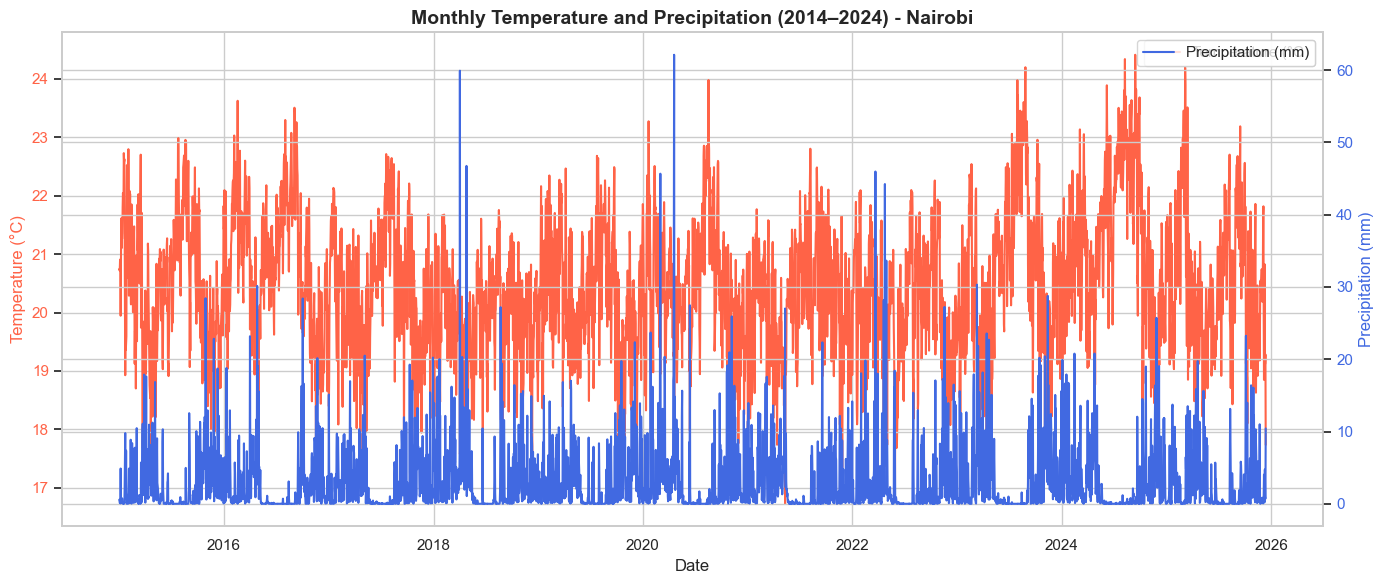

In [14]:
# Seaborn
sns.set_theme(style="whitegrid")

fig, ax1 = plt.subplots(figsize=(14, 6))

# Temperature line
sns.lineplot(
    x='Date', y='Temperature (°C)', data=df_gee_daily,
    color='tomato', label='Temperature (°C)', ax=ax1
)
ax1.set_ylabel("Temperature (°C)", color='tomato')
ax1.tick_params(axis='y', labelcolor='tomato')

# Precipitation (secondary axis)
ax2 = ax1.twinx()
sns.lineplot(
    x='Date', y='Precipitation (mm)', data=df_gee_daily,
    color='royalblue', label='Precipitation (mm)', ax=ax2
)
ax2.set_ylabel("Precipitation (mm)", color='royalblue')
ax2.tick_params(axis='y', labelcolor='royalblue')

# Titles and layout
plt.title("Monthly Temperature and Precipitation (2014–2024) - Nairobi", fontsize=14, weight='bold')
plt.tight_layout()
plt.show()

## Now we load company data to merge with climate data

In [16]:
# Load your car data
data_car = pd.read_csv('/Users/abdullahi/Desktop/vehicle_depression/AutomotiveData.csv', parse_dates=['Date'])
data_car.head(5)


,Date,type_of_car,Base_Loss_USD,flood_risk_flag,Prob_Cover_Deploy,Depreciation_Timeline_months,Expected_Loss_USD
0,01/01/2015,Convertible,61507,1,0.60,72,55754.86
1,02/01/2015,Crossover,46035,0,0.49,35,31445.37
2,03/01/2015,Hatchback,19041,0,0.66,13,16110.42
3,04/01/2015,Hatchback,26375,0,0.23,70,17520.51
4,05/01/2015,Truck,47876,0,0.39,14,40832.93


Before Modelling..
Ensure both datasets use the same date formats then merge daily climate data with the car data on 'Date'

In [29]:
data_car.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4000 entries, 0 to 3999
Data columns (total 7 columns):
 #   Column                        Non-Null Count  Dtype         
---  ------                        --------------  -----         
 0   Date                          4000 non-null   datetime64[ns]
 1   type_of_car                   3964 non-null   object        
 2   Base_Loss_USD                 4000 non-null   int64         
 3   flood_risk_flag               4000 non-null   int64         
 4   Prob_Cover_Deploy             4000 non-null   float64       
 5   Depreciation_Timeline_months  4000 non-null   int64         
 6   Expected_Loss_USD             4000 non-null   float64       
dtypes: datetime64[ns](1), float64(2), int64(3), object(1)
memory usage: 218.9+ KB


In [17]:
# Convert 'Date' column in data_car to datetime objects
data_car['Date'] = pd.to_datetime(data_car['Date'], format='%d/%m/%Y')

# Merge using df as the environment data as the base so we keep all the date of df
data_merged = pd.merge(df_gee_daily, data_car, on='Date', how='left')
# Set Date as index
data_merged = data_merged.set_index('Date')
data_merged.head()


,Precipitation (mm),Temperature (°C),type_of_car,Base_Loss_USD,flood_risk_flag,Prob_Cover_Deploy,Depreciation_Timeline_months,Expected_Loss_USD
Date,,,,,,,,
2015-01-01,0.559692,20.741979,Convertible,61507,1,0.60,72,55754.86
2015-01-02,0.393156,20.720769,Crossover,46035,0,0.49,35,31445.37
2015-01-03,0.118141,20.738995,Hatchback,19041,0,0.66,13,16110.42
2015-01-04,0.126051,20.905557,Hatchback,26375,0,0.23,70,17520.51
2015-01-05,0.054691,20.815737,Truck,47876,0,0.39,14,40832.93


## ML Model Preparation

In [18]:
# Model Deployment
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
# Model Creation
from sklearn.model_selection import train_test_split
from sklearn.metrics import r2_score, mean_squared_error, mean_absolute_error
from sklearn.preprocessing import OneHotEncoder

from sklearn.ensemble import RandomForestRegressor, ExtraTreesRegressor, GradientBoostingRegressor
from sklearn.tree import DecisionTreeRegressor
from sklearn.linear_model import Ridge
from xgboost import XGBRegressor
from sklearn.model_selection import RandomizedSearchCV, TimeSeriesSplit

# Model Deployment
import joblib

# Import streamlit
import streamlit as st


In [19]:
# Prepare Data for ML Modeling
# Define features (X) and target (y)
y = data_merged['Expected_Loss_USD'] # Target variable
X = data_merged.drop(columns=['Expected_Loss_USD']) # Independed


In [20]:
# One-hot encode categorical features
X = pd.get_dummies(X, columns=['type_of_car'], drop_first=True)

In [21]:
# Split the data
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

### Model benchmarking- compare Multiple Models and their performance

In [ ]:
# Model Evaluation metrics helper function R², RMSE, MSE, MAE
def metrics(y_true, y_pred):
    r2 = r2_score(y_true, y_pred)
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    mse = mean_squared_error(y_true, y_pred)
    mae = mean_absolute_error(y_true, y_pred)
    return r2, rmse, mse, mae

# Define candidate models (baseline comparison)
models = {
    "RandomForest": RandomForestRegressor(random_state=42, n_jobs=-1),
    "ExtraTrees": ExtraTreesRegressor(random_state=42, n_jobs=-1),
    "GradientBoosting": GradientBoostingRegressor(random_state=42),
    "Ridge": Ridge(random_state=42),
    "DecisionTree": DecisionTreeRegressor(random_state=42)
}

# add XGBoost
if "HAS_XGB" in globals() and HAS_XGB:
    models["XGBoost"] = XGBRegressor(
        random_state=42,
        n_estimators=600,
        learning_rate=0.05,
        max_depth=6,
        subsample=0.8,
        colsample_bytree=0.8
    )


# Train + evaluate each model
results = []
trained_models = {}

for name, model in models.items():
    print(f"\n--- Training {name} ---")

    model.fit(X_train, y_train)

    # Predict on test set
    y_pred = model.predict(X_test)

    # Compute metrics
    r2, rmse, mse, mae = metrics(y_test, y_pred)

    # Store results
    results.append([name, r2, rmse, mse, mae])
    trained_models[name] = model

    print(f"{name} R²:   {r2:.4f}")
    print(f"{name} RMSE: {rmse:,.2f}")
    print(f"{name} MSE:  {mse:,.2f}")
    print(f"{name} MAE:  {mae:,.2f}")


--- Training RandomForest ---
RandomForest R²:   0.8940
RandomForest RMSE: 3,935.70
RandomForest MSE:  15,489,746.79
RandomForest MAE:  3,099.46

--- Training ExtraTrees ---
ExtraTrees R²:   0.8941
ExtraTrees RMSE: 3,933.81
ExtraTrees MSE:  15,474,894.96
ExtraTrees MAE:  3,079.30

--- Training GradientBoosting ---
GradientBoosting R²:   0.9047
GradientBoosting RMSE: 3,733.11
GradientBoosting MSE:  13,936,080.15
GradientBoosting MAE:  2,953.02

--- Training Ridge ---
Ridge R²:   0.9020
Ridge RMSE: 3,785.51
Ridge MSE:  14,330,100.63
Ridge MAE:  2,977.93

--- Training DecisionTree ---
DecisionTree R²:   0.7974
DecisionTree RMSE: 5,441.78
DecisionTree MSE:  29,612,974.39
DecisionTree MAE:  4,236.10


In [23]:
# Summarize model performance in a table
results_df = (
    pd.DataFrame(results, columns=["Model", "R2", "RMSE", "MSE", "MAE"])
      .sort_values("R2", ascending=False)
      .reset_index(drop=True)
)

print("\n============================")
print("MODEL COMPARISON RESULTS")

print(results_df)

# Pick the best-performing model (highest R² by default)
best_name = results_df.loc[0, "Model"]
best_model = trained_models[best_name]

print(f"Best model so far: {best_name}")


# comment
"""
This cell benchmarks multiple regression models to predict Expected_Loss_USD
and compares their performance on unseen test data.

For each model, it:
- Trains on the training dataset.
- Predicts Expected_Loss_USD on the test dataset.
- Evaluates performance using:
    - R²  : how well predictions explain the variance in actual losses.
    - RMSE: typical prediction error in USD.
    - MSE : squared error, which penalizes large mistakes more heavily.
    - MAE : average absolute error in USD (most interpretable).

The results are summarized in a comparison table and the best-performing
model (highest R² by default) is selected for further tuning and prediction.
Lower RMSE, MSE, and MAE indicate better accuracy.
"""



MODEL COMPARISON RESULTS
              Model        R2         RMSE           MSE          MAE
0  GradientBoosting  0.904652  3733.105965  1.393608e+07  2953.022368
1             Ridge  0.901957  3785.511938  1.433010e+07  2977.927945
2        ExtraTrees  0.894124  3933.814301  1.547489e+07  3079.297613
3      RandomForest  0.894023  3935.701562  1.548975e+07  3099.460465
4      DecisionTree  0.797394  5441.780443  2.961297e+07  4236.098292
Best model so far: GradientBoosting


'\nThis cell benchmarks multiple regression models to predict Expected_Loss_USD\nand compares their performance on unseen test data.\n\nFor each model, it:\n- Trains on the training dataset.\n- Predicts Expected_Loss_USD on the test dataset.\n- Evaluates performance using:\n    - R²  : how well predictions explain the variance in actual losses.\n    - RMSE: typical prediction error in USD.\n    - MSE : squared error, which penalizes large mistakes more heavily.\n    - MAE : average absolute error in USD (most interpretable).\n\nThe results are summarized in a comparison table and the best-performing\nmodel (highest R² by default) is selected for further tuning and prediction.\nLower RMSE, MSE, and MAE indicate better accuracy.\n'

In [24]:
# FINE-TUNING THE BEST MODEL (GradientBoosting)

print("\n--- Fine-tuning GradientBoostingRegressor ---")

# NOTE:
# You already used pd.get_dummies(), so we tune the model directly on X_train.
# Also, GradientBoostingRegressor does NOT use n_jobs.

gb_model = GradientBoostingRegressor(random_state=42)

# Hyperparameter search space (good starting ranges)
param_dist = {
    "n_estimators": [200, 400, 600, 800, 1200],
    "learning_rate": [0.01, 0.03, 0.05, 0.08, 0.1],
    "max_depth": [2, 3, 4, 5],
    "min_samples_split": [2, 5, 10, 20],
    "min_samples_leaf": [1, 2, 4, 8],
    "subsample": [0.6, 0.8, 1.0],
    "max_features": [None, "sqrt", 0.5, 0.8],
}

# CV splitter
cv = TimeSeriesSplit(n_splits=4)

search = RandomizedSearchCV(
    estimator=gb_model,
    param_distributions=param_dist,
    n_iter=30,                 # increase to 50+ if you want deeper tuning
    scoring="r2",
    cv=cv,
    random_state=42,
    n_jobs=-1,
    verbose=1
)

# Fit search on training data
search.fit(X_train, y_train)

# Best tuned model
tuned_gb = search.best_estimator_

# Predict on test set
y_pred = tuned_gb.predict(X_test)

# Evaluate
r2, rmse, mse, mae = metrics(y_test, y_pred)

print("\n=== Tuned GradientBoosting Test Metrics ===")
print("Best params:", search.best_params_)
print(f"R2:   {r2:.4f}")
print(f"RMSE: {rmse:,.2f}")
print(f"MSE:  {mse:,.2f}")
print(f"MAE:  {mae:,.2f}")

# comment
"""
This cell fine-tunes the GradientBoostingRegressor, which performed best
during the model benchmarking stage.

It uses RandomizedSearchCV with a time-aware cross-validation strategy
(TimeSeriesSplit) to identify optimal hyperparameters such as:
- number of trees (n_estimators),
- learning rate,
- tree depth,
- minimum samples per split/leaf,
- subsampling and feature selection.

The tuned model is then evaluated on the test dataset using:
- R²   : overall goodness of fit,
- RMSE : typical prediction error in USD,
- MSE  : squared error emphasizing large mistakes,
- MAE  : average absolute error in USD.

Improved scores indicate better generalization and more reliable
predictions of Expected_Loss_USD.
"""




--- Fine-tuning GradientBoostingRegressor ---
Fitting 4 folds for each of 30 candidates, totalling 120 fits

=== Tuned GradientBoosting Test Metrics ===
Best params: {'subsample': 0.6, 'n_estimators': 800, 'min_samples_split': 2, 'min_samples_leaf': 8, 'max_features': None, 'max_depth': 2, 'learning_rate': 0.01}
R2:   0.9058
RMSE: 3,709.75
MSE:  13,762,247.67
MAE:  2,945.34


'\nThis cell fine-tunes the GradientBoostingRegressor, which performed best\nduring the model benchmarking stage.\n\nIt uses RandomizedSearchCV with a time-aware cross-validation strategy\n(TimeSeriesSplit) to identify optimal hyperparameters such as:\n- number of trees (n_estimators),\n- learning rate,\n- tree depth,\n- minimum samples per split/leaf,\n- subsampling and feature selection.\n\nThe tuned model is then evaluated on the test dataset using:\n- R²   : overall goodness of fit,\n- RMSE : typical prediction error in USD,\n- MSE  : squared error emphasizing large mistakes,\n- MAE  : average absolute error in USD.\n\nImproved scores indicate better generalization and more reliable\npredictions of Expected_Loss_USD.\n'

### SAVE TRAINED MODEL

In [30]:
import joblib

# Save the trained and tuned model
artifact = {
    "model": tuned_gb,
    "feature_names": X.columns.tolist()
}

joblib.dump(artifact, "vehicle_loss_model.pkl")


print("Model saved successfully.")


Model saved successfully.


### LOAD TRAINED MODEL

In [ ]:
import joblib

# Load the trained model
model = joblib.load("vehicle_loss_model.pkl")

print("Model loaded and ready for prediction.")

# we will deploy the model afterwards

Model loaded and ready for prediction.
